<a href="https://colab.research.google.com/github/Parker-P-Wilson/Linear-regression/blob/main/linear_regression_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub scikit-learn tensorflow pandas numpy matplotlib seaborn --quiet

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 10
})

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

TF 2.20.0 | GPU: []


## 1. Import dữ liệu qua `kagglehub`

In [ ]:
import os
import glob
import kagglehub

# Download latest version (auto-cached after first run)
path = kagglehub.dataset_download('nehalbirla/vehicle-dataset-from-cardekho')
print('Path to dataset files:', path)

csv_files = sorted(glob.glob(os.path.join(path, '**/*.csv'), recursive=True))
print(f'CSVs found: {len(csv_files)}')
for f in csv_files:
    print(f'  {f}')

100%|██████████| 292k/292k [00:00<00:00, 617kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4
CSVs found: 4
  /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/CAR DETAILS FROM CAR DEKHO.csv
  /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/Car details v3.csv
  /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car data.csv
  /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/car details v4.csv


In [ ]:
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape} | Columns: {list(df.columns)}')
df.head(3)

Shape: (4340, 8) | Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner


## 2. Auto Categorical Tag Mapping

In [ ]:
TARGET        = 'selling_price'
OHE_THRESHOLD = 6
DROP_COLS     = []

if TARGET not in df.columns:
    TARGET = df.select_dtypes(include=np.number).columns[-1]
    print(f'Target auto-set: {TARGET}')

def auto_encode(df, target, ohe_threshold=6, drop_cols=None):
    drop_cols = drop_cols or []
    df_enc    = df.drop(columns=drop_cols, errors='ignore').copy()
    registry  = {}
    cat_cols  = [c for c in df_enc.select_dtypes(include=['object','category']).columns
                 if c != target]

    print(f'\n{"Column":<25} {"Unique":>7}  {"Strategy"}')
    print('-' * 50)

    for col in cat_cols:
        n  = df_enc[col].nunique(dropna=True)
        df_enc[col].fillna(df_enc[col].mode()[0], inplace=True)

        if n == 2 or n > ohe_threshold:
            le = LabelEncoder()
            df_enc[col] = le.fit_transform(df_enc[col].astype(str))
            strategy = 'LabelEncoder' if n == 2 else 'OrdinalEncoder'
            registry[col] = {'strategy': strategy, 'encoder': le}
        else:
            dummies  = pd.get_dummies(df_enc[col], prefix=col, drop_first=False, dtype=float)
            df_enc   = pd.concat([df_enc.drop(columns=[col]), dummies], axis=1)
            strategy = f'OneHotEncoder → {list(dummies.columns)}'
            registry[col] = {'strategy': 'OneHotEncoder'}

        print(f'{col:<25} {n:>7}  {strategy}')

    df_enc.fillna(df_enc.median(numeric_only=True), inplace=True)
    leftover = [c for c in df_enc.select_dtypes(include='object').columns if c != target]
    df_enc.drop(columns=leftover, inplace=True)
    print(f'\nFinal shape: {df_enc.shape}')
    return df_enc, registry

df_enc, registry = auto_encode(df, TARGET, OHE_THRESHOLD, DROP_COLS)


Column                     Unique  Strategy
--------------------------------------------------
name                         1491  OrdinalEncoder
fuel                            5  OneHotEncoder → ['fuel_CNG', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol']
seller_type                     3  OneHotEncoder → ['seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer']
transmission                    2  LabelEncoder
owner                           5  OneHotEncoder → ['owner_First Owner', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

Final shape: (4340, 18)


## 3. Chuẩn bị dữ liệu

In [ ]:
FEATURES = [c for c in df_enc.columns if c != TARGET]
X        = df_enc[FEATURES].values.astype(np.float32)
y_raw    = df_enc[TARGET].values.astype(np.float32)

skew = float(pd.Series(y_raw).skew())
USE_LOG = skew > 1.0
y = np.log1p(y_raw) if USE_LOG else y_raw
print(f'Target skew: {skew:.2f} → log-transform: {USE_LOG}')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)

sc   = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_val= sc.transform(X_val)
X_te = sc.transform(X_te)

print(f'Train {X_tr.shape} | Val {X_val.shape} | Test {X_te.shape}')

Target skew: 4.89 → log-transform: True
Train (3038, 17) | Val (651, 17) | Test (651, 17)


## 4. Model

In [ ]:
def build_model(n_features, lr=1e-3, dropout=0.2, l2=1e-4):
    reg = regularizers.l2(l2)
    inp = keras.Input(shape=(n_features,))
    x = layers.Dense(256, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout / 2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

model = build_model(X_tr.shape[1])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,665 (194.00 KB)

 Trainable params: 48,769 (190.50 KB)

 Non-trainable params: 896 (3.50 KB)

## 5. Callbacks

In [ ]:
os.makedirs('./checkpoints', exist_ok=True)

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=50, min_delta=1e-4,
    restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    './checkpoints/best_model.keras', monitor='val_loss',
    save_best_only=True, verbose=0
)
cb_log = callbacks.CSVLogger('./checkpoints/log.csv')


class CustomEarlyStopping(callbacks.Callback):
    """EMA-smoothed early stopping — tránh dừng sớm do val_loss dao động."""
    def __init__(self, patience=50, min_delta=1e-4, alpha=0.1):
        super().__init__()
        self.patience = patience; self.min_delta = min_delta
        self.alpha = alpha; self.best = np.inf
        self.wait = 0;  self.ema = None
    def on_epoch_end(self, epoch, logs=None):
        raw = logs.get('val_loss', np.inf)
        self.ema = raw if self.ema is None else self.alpha*raw + (1-self.alpha)*self.ema
        if self.ema < self.best - self.min_delta:
            self.best = self.ema; self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                print(f'\n[CustomES] Dừng tại epoch {epoch+1} (EMA={self.ema:.5f})')


class EpochPrinter(callbacks.Callback):
    """In Train/Val MSE, MAE, R² mỗi epoch."""
    def __init__(self, X_tr, y_tr, X_vl, y_vl, every=1):
        super().__init__()
        self.X_tr=X_tr; self.y_tr=y_tr
        self.X_vl=X_vl; self.y_vl=y_vl; self.every=every
    def on_train_begin(self, logs=None):
        h = f'{"Epoch":>6}  {"Train MSE":>12}  {"Val MSE":>12}  {"Train MAE":>12}  {"Val MAE":>12}  {"Train R2":>10}  {"Val R2":>10}'
        print(f'\n{h}\n{"-"*len(h)}')
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % self.every != 0: return
        yh_tr = self.model.predict(self.X_tr, verbose=0).flatten()
        yh_vl = self.model.predict(self.X_vl, verbose=0).flatten()
        print(f'{epoch+1:>6}  {logs["loss"]:>12.5f}  {logs["val_loss"]:>12.5f}  '
              f'{logs["mae"]:>12.5f}  {logs["val_mae"]:>12.5f}  '
              f'{r2_score(self.y_tr, yh_tr):>10.4f}  {r2_score(self.y_vl, yh_vl):>10.4f}')

print('Callbacks sẵn sàng')

Callbacks sẵn sàng


## 6. Training

In [ ]:
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=2000, batch_size=256,
    callbacks=[
        EpochPrinter(X_tr, y_tr, X_val, y_val, every=1),
        cb_early_stop,          # patience=50
        CustomEarlyStopping(patience=50),  # EMA-smoothed, cùng patience
        cb_reduce_lr,
        cb_ckpt, cb_log,
    ],
    verbose=0
)
print(f'\nHoàn thành — {len(history.history["loss"])} epochs')


 Epoch     Train MSE       Val MSE     Train MAE       Val MAE    Train R2      Val R2
--------------------------------------------------------------------------------------
     1     148.34308     155.86716      12.13990      12.46007   -222.6887   -214.5252
     2     112.76988     137.67697      10.56758      11.71197   -196.3307   -189.3678
     3      81.19891     110.30157       8.92469      10.47773   -157.0096   -151.5072
     4      52.85038      80.64947       7.11707       8.94306   -114.6075   -110.4979
     5      28.91054      53.31810       5.12034       7.25283    -75.6315    -72.6983
     6      12.07853      32.52652       3.06581       5.64373    -45.9510    -43.9433
     7       4.55861      21.63642       1.73430       4.57385    -30.2461    -28.8821
     8       2.79115      18.86211       1.31754       4.25620    -26.2496    -25.0451
     9       2.71431      20.50134       1.29964       4.44067    -28.6695    -27.3121
    10       2.25026      22.26681       1

## 7. Đánh giá — Metrics

In [ ]:
def get_metrics(y_true, y_pred, use_log=False):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if use_log:
        yo, yp = np.expm1(y_true), np.expm1(y_pred)
        return {'mse': mse, 'mae': mae, 'rmse': np.sqrt(mse), 'r2': r2,
                'rmse_orig': np.sqrt(mean_squared_error(yo,yp)),
                'mae_orig': mean_absolute_error(yo,yp),
                'r2_orig': r2_score(yo,yp)}
    return {'mse': mse, 'mae': mae, 'rmse': np.sqrt(mse), 'r2': r2}

yp_tr  = model.predict(X_tr,  verbose=0).flatten()
yp_val = model.predict(X_val, verbose=0).flatten()
yp_te  = model.predict(X_te,  verbose=0).flatten()

m_tr  = get_metrics(y_tr,  yp_tr,  USE_LOG)
m_val = get_metrics(y_val, yp_val, USE_LOG)
m_te  = get_metrics(y_te,  yp_te,  USE_LOG)

summary = pd.DataFrame([m_tr, m_val, m_te],
    index=['Train', 'Validation', 'Test']).round(5)
print(summary.to_string())

                mse      mae     rmse       r2     rmse_orig      mae_orig  r2_orig
Train       0.18369  0.32913  0.42859  0.73707  343474.48306  163204.03125  0.66411
Validation  0.22230  0.36384  0.47149  0.69256  302300.29933  166281.29688  0.62800
Test        0.21910  0.35075  0.46808  0.69134  431077.31984  168409.64062  0.46240


## 8. 📊 Biểu đồ đánh giá

4 biểu đồ cốt lõi trên **1 figure duy nhất**:

| # | Biểu đồ | Đánh giá được gì |
|---|---|---|
| 1 | **Learning Curves** | Model có hội tụ không? Có overfit không? |
| 2 | **Predicted vs Actual** | Dự đoán có bám sát thực tế không? |
| 3 | **Residual Distribution** | Sai số có phân phối chuẩn quanh 0 không? |
| 4 | **Feature Importance** | Feature nào quan trọng nhất? |

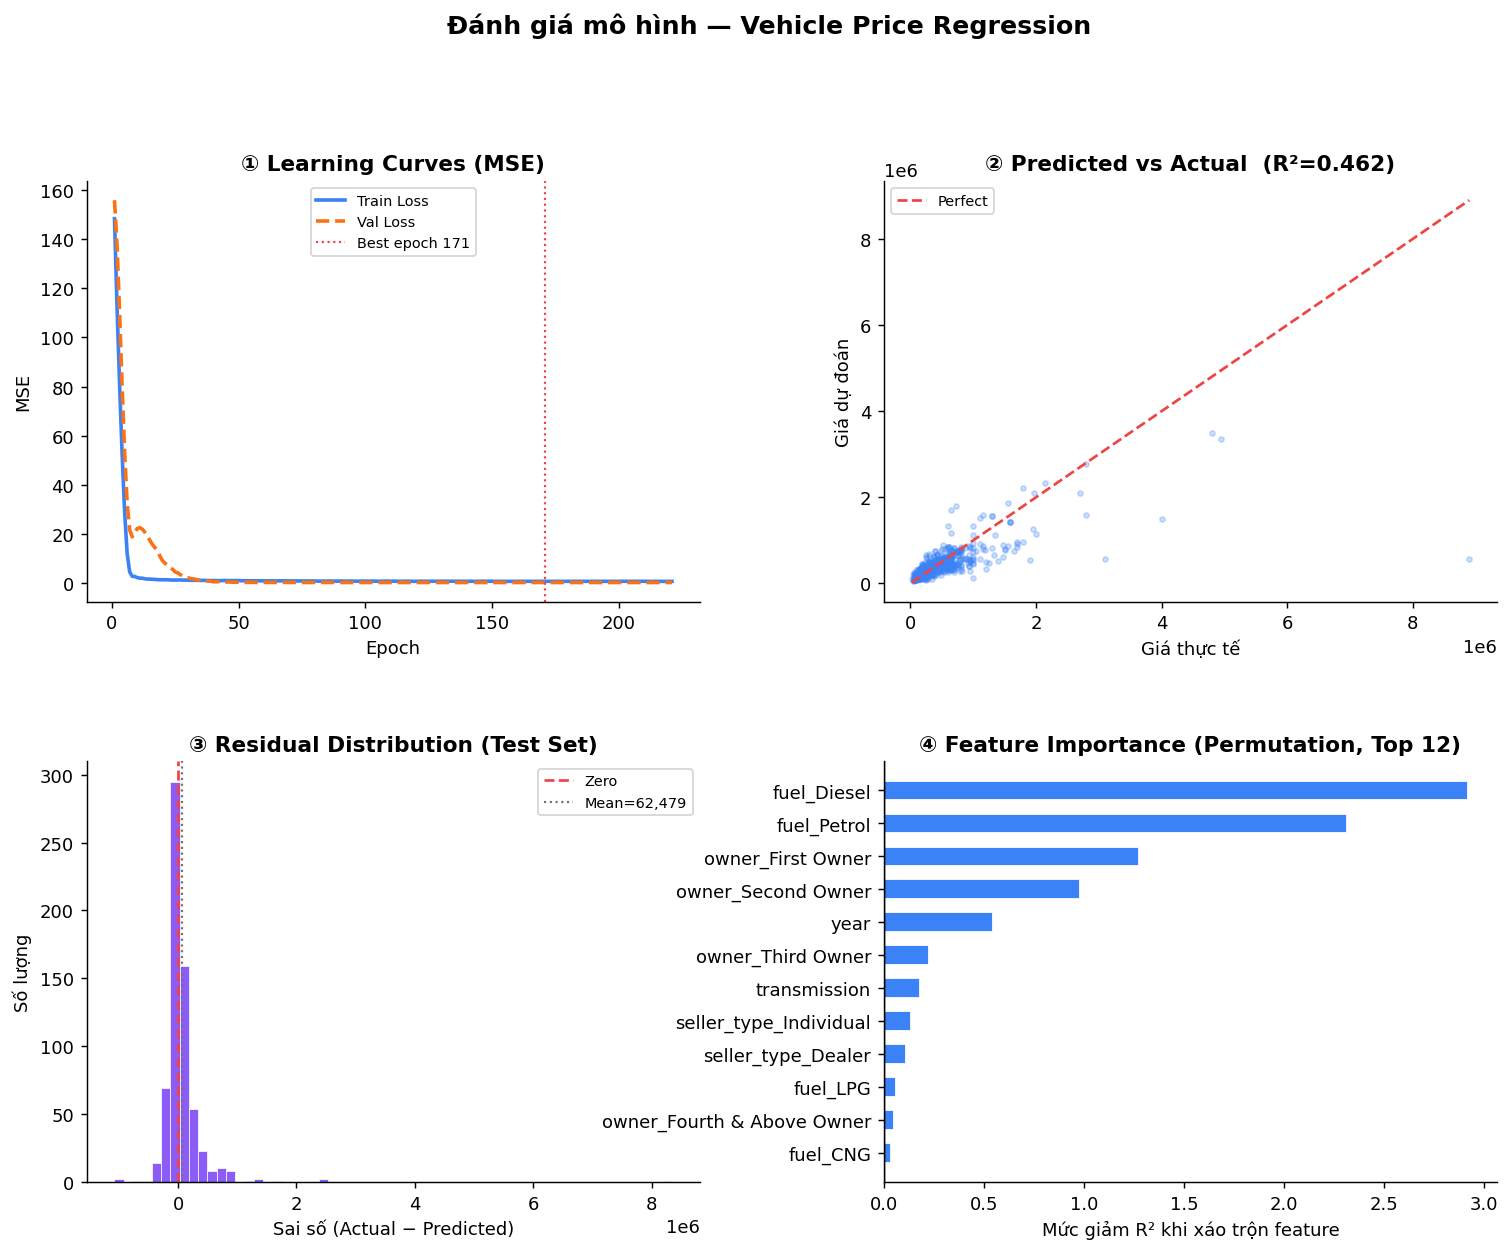

Đã lưu: ./checkpoints/evaluation.png


In [ ]:
# ── Chuẩn bị dữ liệu cho biểu đồ ────────────────────────────────────────
hist   = history.history
ep     = range(1, len(hist['loss']) + 1)
best_e = int(np.argmin(hist['val_loss'])) + 1

y_disp  = np.expm1(y_te)    if USE_LOG else y_te
yp_disp = np.expm1(yp_te)   if USE_LOG else yp_te
resid   = y_disp - yp_disp

# ── Permutation importance (nhanh — 5 lần lặp) ───────────────────────────
class _W(BaseEstimator, RegressorMixin):
    def __init__(self, m): self.model = m
    def fit(self, X, y):   return self
    def predict(self, X):  return self.model.predict(X, verbose=0).flatten()

perm = permutation_importance(_W(model), X_te, y_te,
                               n_repeats=5, random_state=SEED, scoring='r2')
fi = pd.DataFrame({'Feature': FEATURES,
                   'Importance': perm.importances_mean})\
       .sort_values('Importance', ascending=False).head(12)

# ── Layout: 2×2 grid ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

BLUE   = '#3B82F6'
ORANGE = '#F97316'
RED    = '#EF4444'
PURPLE = '#8B5CF6'
GRAY   = '#6B7280'

# ── 1. Learning Curves ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ep, hist['loss'],     color=BLUE,   lw=2,   label='Train Loss')
ax1.plot(ep, hist['val_loss'], color=ORANGE, lw=2,   label='Val Loss', ls='--')
ax1.axvline(best_e, color=RED, lw=1.2, ls=':', label=f'Best epoch {best_e}')
ax1.set_title('① Learning Curves (MSE)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE')
ax1.legend(fontsize=8)

# ── 2. Predicted vs Actual ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_disp, yp_disp, alpha=0.25, s=8, color=BLUE, rasterized=True)
lims = [min(y_disp.min(), yp_disp.min()), max(y_disp.max(), yp_disp.max())]
ax2.plot(lims, lims, color=RED, lw=1.5, ls='--', label='Perfect')
r2_te = m_te.get('r2_orig', m_te['r2'])
ax2.set_title(f'② Predicted vs Actual  (R²={r2_te:.3f})', fontweight='bold')
ax2.set_xlabel('Giá thực tế'); ax2.set_ylabel('Giá dự đoán')
ax2.legend(fontsize=8)

# ── 3. Residual Distribution ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(resid, bins=60, color=PURPLE, edgecolor='white', linewidth=0.4)
ax3.axvline(0,              color=RED,  lw=1.5, ls='--', label='Zero')
ax3.axvline(resid.mean(),   color=GRAY, lw=1.2, ls=':',  label=f'Mean={resid.mean():,.0f}')
ax3.set_title('③ Residual Distribution (Test Set)', fontweight='bold')
ax3.set_xlabel('Sai số (Actual − Predicted)'); ax3.set_ylabel('Số lượng')
ax3.legend(fontsize=8)

# ── 4. Feature Importance ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
colors = [BLUE if v >= 0 else RED for v in fi['Importance']]
ax4.barh(fi['Feature'][::-1], fi['Importance'][::-1],
         color=colors[::-1], edgecolor='white', height=0.6)
ax4.axvline(0, color='black', lw=0.8)
ax4.set_title('④ Feature Importance (Permutation, Top 12)', fontweight='bold')
ax4.set_xlabel('Mức giảm R² khi xáo trộn feature')

fig.suptitle('Đánh giá mô hình — Vehicle Price Regression',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('./checkpoints/evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu: ./checkpoints/evaluation.png')

## 9. Kết quả cuối

In [ ]:
print('=' * 45)
print('  KẾT QUẢ CUỐI CÙNG')
print('=' * 45)
for split, m in [('Train', m_tr), ('Validation', m_val), ('Test', m_te)]:
    r2  = m.get('r2_orig', m['r2'])
    rmse= m.get('rmse_orig', m['rmse'])
    mae = m.get('mae_orig', m['mae'])
    print(f'  {split:<12} R²={r2:.4f}  RMSE={rmse:,.0f}  MAE={mae:,.0f}')
print('=' * 45)
print(f'  Best epoch  : {best_e}')
print(f'  Features    : {len(FEATURES)}')
print(f'  Log target  : {USE_LOG}')

  KẾT QUẢ CUỐI CÙNG
  Train        R²=0.6641  RMSE=343,474  MAE=163,204
  Validation   R²=0.6280  RMSE=302,300  MAE=166,281
  Test         R²=0.4624  RMSE=431,077  MAE=168,410
  Best epoch  : 171
  Features    : 17
  Log target  : True
